# Introduction

This is the basic reproduction experiment for Yao et al., "Dynamic Word Embeddings for Evolving Semantic Discovery".
It is based on the source code provided in their
[GitHub repository](https://github.com/yifan0sun/DynamicWord2Vec)
and aims to simplify the experiment, update it to a modern Python setup, and ultimately validate the findings from the authors.

# Setup

## Imports

In [1]:
# file io
import scipy.io as sio

# machine learning
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import pandas as pd

# analyses and plots
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE

## Data setup
The experiment relies on files from the researchers dropbox folder. These files are saved in the data directory first.

In [2]:
%run ../setup/setup.py

Target data directory: /home/jovyan/Semantic-Embedding-Evolution/data
Data seems to be loaded already. Skipping download.


## Static variables

In [3]:
seed = 42
years = range(1990, 2017)
vocab_size = 20936
embeddings_file = "../data/emb_static.mat"
word_id_file = "../data/wordIDHash.csv"
train_path = "../data/wordPairPMI_"

## Setup static embeddings

In [4]:
static_embeddings = sio.loadmat(embeddings_file)["emb"]
static_embeddings = torch.from_numpy(static_embeddings).float()

## Setup word to id mapping

In [5]:
df_word_id = pd.read_csv(word_id_file, header=None, names=["id", "word", "count"])

wordlist = [f"missing_word_idx_{i}" for i in range(vocab_size)]

for _, row in df_word_id.iterrows():
    wordlist[int(row["id"])] = str(row["word"])

word2Id = {word: i for i, word in enumerate(wordlist)}

# Dataset

In [6]:
class DynamicPMIDataset(Dataset):
    def __init__(self, time_steps, train_path, vocab_size):
        self.time_steps = time_steps
        self.train_path = train_path
        self.vocab_size = vocab_size

    def __len__(self):
        return len(self.time_steps)

    def __getitem__(self, idx):
        t = self.time_steps[idx]
        df = pd.read_csv(f"{self.train_path}{t}.csv")

        # shift the indices to start from 0 instead of 1
        indices = torch.from_numpy(df.values[:, :2] - 1).long()
        values = torch.from_numpy(df.values[:, 2]).float()

        # Initialize dense matrix
        dense_pmi = torch.zeros((self.vocab_size, self.vocab_size), dtype=torch.float32)

        # symmetrize
        dense_pmi[indices[:, 0], indices[:, 1]] = values
        dense_pmi[indices[:, 1], indices[:, 0]] = values

        return t, dense_pmi

# Model

In [23]:
class DynamicEmbeddingModel(nn.Module):
    def __init__(self, n_times, static_embeddings):
        super().__init__()
        self.U = nn.Parameter(static_embeddings.unsqueeze(0).repeat(n_times, 1, 1))
        self.V = nn.Parameter(static_embeddings.unsqueeze(0).repeat(n_times, 1, 1))

    def forward(self, t, pmi, lam, tau, gam, emph):
        U_t, V_t = self.U[t], self.V[t]
        pred = torch.mm(U_t, V_t.t())

        # difference to predicted embeddings
        mask = (pmi != 0).float() # calculate loss only for words with cooccurences
        weight_matrix = mask * emph + (1 - mask) * 0
        recon_loss = torch.sum(weight_matrix * (pmi - pred)**2)

        # L2 regularization on U and V
        reg_loss = lam * (torch.sum(U_t**2) + torch.sum(V_t**2))

        # temporal smoothing
        temp_loss = 0
        if t > 0:
            temp_loss += tau * (torch.sum((U_t - self.U[t-1])**2) + torch.sum((V_t - self.V[t-1])**2))
        if t < self.U.size(0) - 1:
            temp_loss += tau * (torch.sum((U_t - self.U[t+1])**2) + torch.sum((V_t - self.V[t+1])**2))

        # alignment constraint between U and V
        align_loss = gam * torch.sum((U_t - V_t)**2)

        # print loss components for debugging
        if t == 0: print(f"recon_loss: {recon_loss}, reg_loss; {reg_loss}, temp_loss: {temp_loss}, align_loss: {align_loss}")

        return recon_loss + reg_loss + temp_loss + align_loss

# Training

## Hyperparameters

In [24]:
n_epochs = 20 # total passes over the data
lam = 1 # l2 regularizer
tau = 100000 # smoothing regularizer
gam = 100 # alignment forcing regularizer
learning_rate = 1e-4
emph = 50 # emphasis of non-zero coocurrence terms

## Training procedure

In [25]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = DynamicEmbeddingModel(len(years), static_embeddings).to(device)
optimizer = optim.Adam(model.parameters(), lr=learning_rate)
# optimizer = torch.optim.SGD(model.parameters(), lr=lr)
dataset = DynamicPMIDataset(range(len(years)), train_path, vocab_size)
loader = DataLoader(dataset, batch_size=1)

In [ ]:
for epoch in range(n_epochs):
    print(f"Epoch {epoch}")
    shuffled_years = torch.arange(len(years)) if epoch < 2 else torch.randperm(len(years))

    for y_idx in shuffled_years:
        # get dense data sample
        year, pmi = dataset[y_idx.item()]
        year = torch.tensor(year).to(device)
        pmi = pmi.to(device)

        # clear gradient
        optimizer.zero_grad()

        # forward pass
        loss = model(year, pmi, lam=lam, tau=tau, gam=gam, emph=emph)
        loss.backward()
        optimizer.step()

    with torch.no_grad():
        drift = torch.norm(model.U[0] - model.U[-1]).item()
        print(f"Total embedding drift magnitude {years[0]} to {years[-1]}: {drift:.4f}")

print("Training finished")

Epoch 0
recon_loss: 2062861696.0, reg_loss; 135757.234375, temp_loss: 0.0, align_loss: 0.0
Total embedding drift magnitude 1990 to 2016: 0.5312
Epoch 1
recon_loss: 2060306944.0, reg_loss; 135684.25, temp_loss: 82024.1953125, align_loss: 2.4246799013027953e-10


# Output visualization

## Example embedding over time

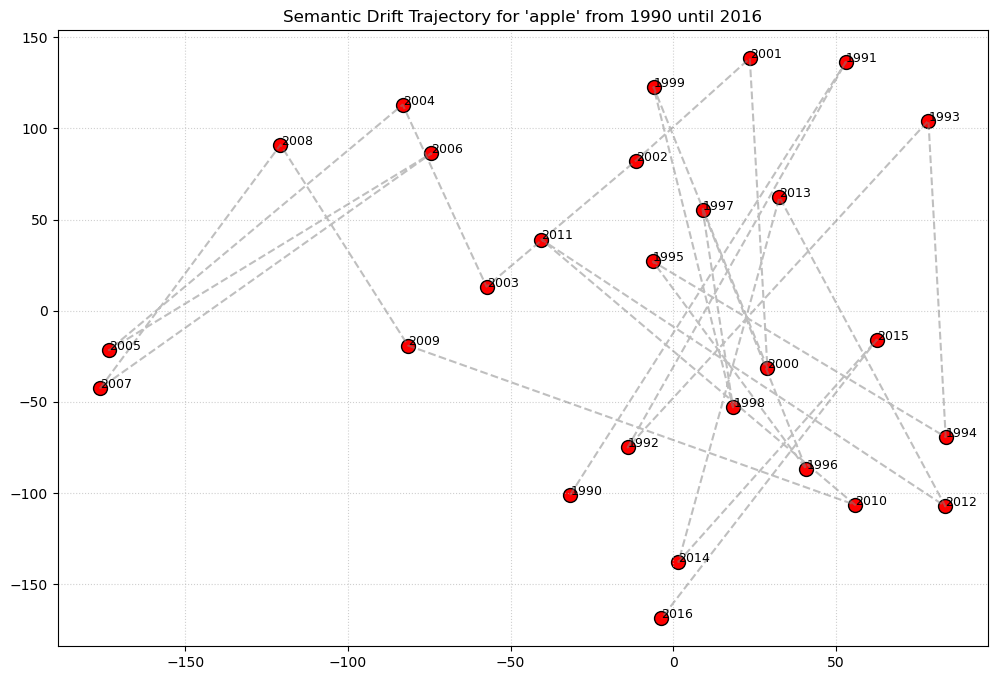

In [88]:
word = "apple"
word_idx = word2Id[word]

# generate embeddings
model.eval()
with torch.no_grad():
    embs = model.U[list(range(len(years))), word_idx, :].detach().cpu().numpy()

# reduce to 2 dimensions
tsne = TSNE(n_components=2, perplexity=5, random_state=seed, init="pca")
Z = tsne.fit_transform(embs)

# plot
plt.figure(figsize=(12, 8))
plt.plot(Z[:, 0], Z[:, 1], linestyle="--", color="gray", alpha=0.5)

for i, year in enumerate(years):
    plt.scatter(Z[i, 0], Z[i, 1], color="red", s=100, edgecolors="black")
    plt.text(Z[i, 0] + 0.05, Z[i, 1] + 0.05, f"{year}", fontsize=9)

plt.title(f"Semantic Drift Trajectory for '{word}' from {years[0]} until {years[-1]}")
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

In [89]:
import pandas as pd
import torch
import torch.nn.functional as F

def get_temporal_neighbors(target_word, n_top=5):
    if target_word not in word2Id:
        return f"Word '{target_word}' not in vocabulary."
    
    target_idx = word2Id[target_word]
    results = []
    
    # Switch model to eval mode
    model.eval()
    
    with torch.no_grad():
        # Bring U to CPU to avoid OOM during analysis
        # Shape: [n_years, vocab_size, 50]
        all_U = model.U.detach().cpu()
        
        for i, year in enumerate(years):
            # 1. Get embedding for this year
            year_emb = all_U[i] # [20936, 50]
            target_vec = year_emb[target_idx].unsqueeze(0) # [1, 50]
            
            # 2. Compute similarity against all words for THIS specific year
            sims = F.cosine_similarity(target_vec, year_emb)
            
            # 3. Get top K (n_top + 1 to account for the word itself)
            scores, indices = torch.topk(sims, n_top + 1)
            
            neighbor_list = []
            for idx in indices.tolist():
                word = wordlist[idx]
                if word.lower() == target_word.lower():
                    continue
                neighbor_list.append(word)
                if len(neighbor_list) == n_top:
                    break
            
            results.append({
                "Year": year,
                "Top Neighbors": ", ".join(neighbor_list)
            })

    return pd.DataFrame(results)

# Run the analysis
history_df = get_temporal_neighbors("apple", n_top=6)
print(history_df.to_string(index=False))

 Year                                      Top Neighbors
 1990 blackberry, apples, chips, processor, chip, server
 1991 blackberry, apples, chips, processor, chip, server
 1992 blackberry, apples, chips, processor, chip, server
 1993 blackberry, apples, chips, processor, chip, server
 1994 blackberry, apples, chips, processor, chip, server
 1995 blackberry, apples, chips, processor, chip, server
 1996 blackberry, apples, chips, processor, chip, server
 1997 blackberry, apples, chips, processor, chip, server
 1998 blackberry, apples, chips, processor, chip, server
 1999 blackberry, apples, chips, processor, chip, server
 2000 blackberry, apples, chips, processor, chip, server
 2001 blackberry, apples, chips, processor, chip, server
 2002 blackberry, apples, chips, processor, chip, server
 2003 blackberry, apples, chips, processor, chip, server
 2004 blackberry, apples, chips, processor, chip, server
 2005 blackberry, apples, chips, processor, chip, server
 2006 blackberry, apples, chips